654


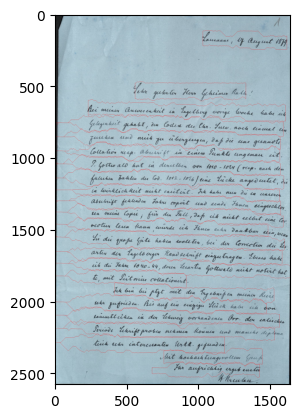

In [49]:
from mysql import connector
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np


cnx = connector.connect(user='root', password='root',
                              host='172.17.0.5',
                              database='textline_app_db')
cursor = cnx.cursor()

query = ("SELECT doc_id, doc_path, output, status FROM documents WHERE created_at > '2025-04-08 17'")
cursor.execute(query)
d_id, path, polygons, status = None, None, None, None
for i, (doc_id, doc_path, output, stat)in enumerate(cursor):
    d_id, path, polygons, status = doc_id, doc_path, output, stat
    if i ==0:
        break

print(d_id)
# print(polygons)
polygons = eval(polygons)['polygons']

image = cv2.imread(os.path.join('/data3/amalj/template_api/store/user_files/uploaded_documents', path))


image2 = image.copy()
for line in polygons:
    image2 = cv2.polylines(image2, [np.array(line)], color=(255, 0, 0), thickness=1, isClosed=True)

plt.imshow(image2)

In [7]:
import imagesize
width, height = imagesize.get('/data3/amalj/template_api/store/user_files/uploaded_documents/d657f788-e444-41b1-ad1b-9d30b0649106/040005.jpg')
width, height

(1640, 2576)

In [6]:
from fastapi import APIRouter, Depends, HTTPException, status, Response
from sqlalchemy.orm import Session

from src.database import crud, schemas, models # Import models for type hinting
from src.api import deps
from uuid import UUID

job_id = 'f5eb1ddc-2567-421a-92d5-a67e9013c952'
job_id =UUID(job_id)
db = next(deps.get_db())
db_job = crud.get_job_by_job_id(db=db, job_id_bytes=job_id.bytes)

In [10]:
db_job